## Capstone Project Scirpt


**Acknowledgement**: 
- Boxiang Liu
- Festus Nyasimi (for providing us with Predixcan predictions)
- Saideep Gona
- Temidayo Adeluwa


Copyright 2021 DeepMind Technologies Limited

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

     https://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.

## Introduction

In this notebook, we explore how Enformer can be used to predict the expression of protein-coding genes. We utilized some code from the [original Enformer usage colab notebook](https://colab.research.google.com/github/deepmind/deepmind_research/blob/master/enformer/enformer-usage.ipynb). Here, we showcase how the Enformer model can be used to predict gene expression on a GEUVADIS/1000 genomes dataset, and compare the predictions with true expression. 

**"Effective gene expression prediction from sequence by integrating long-range interactions"**

Žiga Avsec, Vikram Agarwal, Daniel Visentin, Joseph R. Ledsam, Agnieszka Grabska-Barwinska, Kyle R. Taylor, Yannis Assael, John Jumper, Pushmeet Kohli, David R. Kelley

### Steps

This notebook demonstrates how to
- Prepare inputs for Enformer to make predictions
- Make predictions with Enformer and produce figures
- Similiarly, Make predictions with PrediXcan and produce figures
- Compare predictions with true expression

## Setup

Google Colab gives us some GPU access. This limited GPU is available to anyone with a Google account, who has signed up to use Colaboratory. We will begin by changing the runtime type to GPU. Follow the instruction below by clicking on "Runtime -> Change runtime type -> GPU" in the menu bar below the title of this notebook. 

**Start the colab kernel with GPU**: Runtime -> Change runtime type -> GPU


Below, we import tensorflow as tf, and check that the runtime has been changed to GPU. 

In [1]:
import tensorflow as tf
# Make sure the GPU is enabled 
assert tf.config.list_physical_devices('GPU'), 'Start the colab kernel with GPU: Runtime -> Change runtime type -> GPU'

kipoiseq is a package that helps us to extract sequences from fasta files given some intervals. We will install the package. 

In [2]:
!pip install kipoiseq==0.5.2 --quiet > /dev/null
# You can ignore the pyYAML error

Biopython is a python package that helps us do many bioinfomatic analysis in python

In [3]:
!pip install Biopython

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 2.3 MB 14.5 MB/s 


### Setting up our environments

Import packages that we need later. 

In [4]:
import tensorflow_hub as hub # for interacting with saved models and tensorflow hub
import joblib
import gzip # for manipulating compressed files
import kipoiseq # for manipulating fasta files
from kipoiseq import Interval # same as above, really
import pyfaidx # to index our reference genome file
import pandas as pd # for manipulating dataframes
import numpy as np # for numerical computations
import matplotlib.pyplot as plt # for plotting
import matplotlib as mpl # for plotting
import seaborn as sns # for plotting
import pickle # for saving large objects
import os, sys # functions for interacting with the operating system
import random  
import glob

%matplotlib inline
%config InlineBackend.figure_format = 'retina'


Create a folder called "Capstone_Project_2022" in Google Drive to store results and data pernemently  

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
if not os.path.exists("/content/drive/MyDrive/Capstone_Project_2022/results/"):
  !mkdir -p "/content/drive/MyDrive/Capstone_Project_2022/results/"

In [7]:
local_path = '/content/drive/MyDrive/Capstone_Project_2022/'

In [8]:
transform_path = 'gs://dm-enformer/models/enformer.finetuned.SAD.robustscaler-PCA500-robustscaler.transform.pkl'
model_path = 'https://tfhub.dev/deepmind/enformer/1'
fasta_file = '/content/drive/MyDrive/Capstone_Project_2022/genome.fa'

We may inspect the tracks used to train the model. The CAGE prediction corresponding to B lymphoblastoid cell line is index 5110. We use B lymphoblastoid cell line predictions here because that is the cell line used to generate GEUVADIS gene expression data. You can copy the https link, paste in another tab in your browser and look through the large txt file for other tracks. 

In [9]:
# Download targets from Basenji2 dataset 
# Cite: Kelley et al Cross-species regulatory sequence activity prediction. PLoS Comput. Biol. 16, e1008050 (2020).
targets_txt = 'https://raw.githubusercontent.com/calico/basenji/master/manuscripts/cross2020/targets_human.txt'
df_targets = pd.read_csv(targets_txt, sep='\t')
df_targets[df_targets.index==5110]

,index,genome,identifier,file,clip,scale,sum_stat,description
5110,5110,0,CNhs12333,/home/drk/tillage/datasets/human/cage/fantom/C...,384,1,sum,CAGE:B lymphoblastoid cell line: GM12878 ENCOD...


### Download files


We need to download some files. Give it a moment. 
We will download the following files:
- The reference genome fasta file (we will also index this file in the process)
- A text file for the transcription start sites for each chromosome 
- Per chromosome files that has annotation for the genes
- A compressed file that contains the variant bed files for the genes and their locations. 

Credit to Genome Reference Consortium: https://www.ncbi.nlm.nih.gov/grc

Schneider et al 2017 http://dx.doi.org/10.1101/gr.213611.116: Evaluation of GRCh38 and de novo haploid genome assemblies demonstrates the enduring quality of the reference assembly

Make a data directory, and download the necessary bed files and chromosome annotation files

**NB:** You may decide to download these files into your "/content/drive/MyDrive/Enformer_Hackathon_2022/" directory. **You don't need to do this**. But if you want permanent access to the files we use in this notebook, you can change the path from "/root/data/" to "/content/drive/MyDrive/Enformer_Hackathon_2022/", and modify what you need accordingly. 

The next line of code will download the reference genome fasta file and index this file. 

In [10]:
# reference genome and indexed
if not os.path.exists('/content/drive/MyDrive/Capstone_Project_2022/genome.fa'):
  !wget -O - https://hgdownload.soe.ucsc.edu/goldenPath/hg19/bigZips/hg19.fa.gz | gunzip -c > {fasta_file}
  pyfaidx.Faidx(fasta_file)

The next lines of code will download the variation bed files, and we have created links to help us download the variation bed files for each chromosome, for each gene.

In [11]:
chrom_bed_downloads = pd.read_csv("https://uchicago.box.com/shared/static/du77wf31li38tciv8imivwu57svae03p.csv")
chrom_bed_downloads.index = chrom_bed_downloads["chroms"]

#chrom_bed_downloads


In [12]:
! head /content/drive/MyDrive/Capstone_Project_2022/data/individual_beds/chr11/chr11_AMPD3.bed

#CHROM	POS	REF	ALT	HG00096	HG00097	HG00099	HG00100	HG00101	HG00102	HG00103	HG00104	HG00105	HG00106	HG00108	HG00109	HG00110	HG00111	HG00112	HG00114	HG00115	HG00116	HG00117	HG00118	HG00119	HG00120	HG00121	HG00122	HG00123	HG00125	HG00126	HG00127	HG00128	HG00129	HG00130	HG00131	HG00132	HG00133	HG00134	HG00135	HG00136	HG00137	HG00138	HG00139	HG00141	HG00142	HG00143	HG00145	HG00146	HG00148	HG00149	HG00150	HG00151	HG00152	HG00154	HG00155	HG00156	HG00157	HG00158	HG00159	HG00160	HG00171	HG00173	HG00174	HG00176	HG00177	HG00178	HG00179	HG00180	HG00181	HG00182	HG00183	HG00185	HG00186	HG00187	HG00188	HG00189	HG00231	HG00232	HG00233	HG00234	HG00235	HG00236	HG00238	HG00239	HG00240	HG00242	HG00243	HG00244	HG00245	HG00246	HG00249	HG00250	HG00251	HG00252	HG00253	HG00255	HG00256	HG00257	HG00258	HG00259	HG00260	HG00261	HG00262	HG00263	HG00264	HG00265	HG00266	HG00267	HG00268	HG00269	HG00271	HG00272	HG00273	HG00274	HG00275	HG00276	HG00277	HG00278	HG00280	HG00281	HG00282	HG00284	HG00285	HG00306	HG00308	HG003

We will define a function to help us download bed variation files for a given gene or list of genes

In [13]:
def download_chrom_beds(chromosome, genes, downloads_table=chrom_bed_downloads):
  '''
  Downloads bed/variation files for a chromosome and list of genes
  '''

  link = downloads_table.loc[str(chromosome), "link"]
  print(link)
  chr_which = 'chr' + chromosome
  for gene in genes:
    if os.path.exists('/content/drive/MyDrive/Capstone_Project_2022/data/individual_beds/chr' + chromosome + '/chr' + chromosome + '_' + gene + '.bed'): # if the file is in the folder, no need to download again
      continue
    !curl -L {link} --output /content/drive/MyDrive/Capstone_Project_2022/data/chr_{chromosome}_bed.tar.gz && cd /content/drive/MyDrive/Capstone_Project_2022/data/ && tar -zxf /content/drive/MyDrive/Capstone_Project_2022/data/chr_{chromosome}_bed.tar.gz ./individual_beds/{chr_which}/{chr_which}_{gene}.bed

    # remove the download tar.gz file
    !rm /content/drive/MyDrive/Capstone_Project_2022/data/chr_{chromosome}_bed.tar.gz

# Download TSS file
You can pass in a list of genes as long as they are all located on that chromosome. 

In the next block of code, we download the TSS for each chromosome and the genes in that chromosome, as wells as the per chromosome gene annotations. We need this information to estimate predictions. 


In [14]:
if not os.path.exists("/content/drive/MyDrive/Capstone_Project_2022/data/gene_chroms"):
  !mkdir -p /content/drive/MyDrive/Capstone_Project_2022/data/gene_chroms #creates a folder to hold our files

!curl -L https://uchicago.box.com/shared/static/perc3uabzzd267cbp8zc0inwgrmur7pu.gz --output /content/drive/MyDrive/Capstone_Project_2022/data/chr_tss.tar.xz && cd /content/drive/MyDrive/Capstone_Project_2022/data/ && tar -zxf /content/drive/MyDrive/Capstone_Project_2022/data/chr_tss.tar.xz

!curl -L https://uchicago.box.com/shared/static/e2kiwrjlgqqio0pc37a2iz7l5bqbv57u.gz --output /content/drive/MyDrive/Capstone_Project_2022/data/gene_chroms/gene_chroms.tar.gz && cd /content/drive/MyDrive/Capstone_Project_2022/data/gene_chroms/ && tar -zxf /content/drive/MyDrive/Capstone_Project_2022/data/gene_chroms/gene_chroms.tar.gz


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100     7    0     7    0     0      5      0 --:--:--  0:00:01 --:--:--     0
100 1783k  100 1783k    0     0   717k      0  0:00:02  0:00:02 --:--:-- 4924k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100     6    0     6    0     0      5      0 --:--:--  0:00:01 --:--:--    10
100  728k  100  728k    0     0   294k      0  0:00:02  0:00:02 --:--:-- 65.0M


### How do we want to go about using Enformer given all these files we just downloaded?

As we know, enformer's input is a single strand genome sequence. Yet, we are interested in predicting on population level data which includes individual-specific variation. To get around this limitation, we will treat each individual as the sum of their haplotypes. Using the phased variant data around each gene (stored in the variant bed files) to modify the reference sequence, we can create two distinct haplotype sequences for each individual. The sum of both of Enformer's haplotype predictions serves as an individual-specific, additive estimate which we can correlate with true predictions. Together, the files we downloaded give us all the information we need to build these haplotype sequences. 

Althought enformer predicts a wide array of functional output, we will focus here on gene expression in lymphoblastoid cells allowing for correlation against ground truth Geuvadis gene expression data.

There are many functions that we have defined in the next code block. You can explore them later, but for now, simply run the block by clicking on the play button. 

### Code

Next, we have some functions that will help us along the way. Classes and methods defined in this code block can be found in the [original Enformer usage colab notebook](https://colab.research.google.com/github/deepmind/deepmind_research/blob/master/enformer/enformer-usage.ipynb). 

In [15]:
# @title `Enformer`, `EnformerScoreVariantsNormalized`, `EnformerScoreVariantsPCANormalized`,
SEQUENCE_LENGTH = 393216

class Enformer:

  def __init__(self, tfhub_url):
    self._model = hub.load(tfhub_url).model

  def predict_on_batch(self, inputs):
    predictions = self._model.predict_on_batch(inputs)
    return {k: v.numpy() for k, v in predictions.items()}

  @tf.function
  def contribution_input_grad(self, input_sequence,
                              target_mask, output_head='human'):
    input_sequence = input_sequence[tf.newaxis]

    target_mask_mass = tf.reduce_sum(target_mask)
    with tf.GradientTape() as tape:
      tape.watch(input_sequence)
      prediction = tf.reduce_sum(
          target_mask[tf.newaxis] *
          self._model.predict_on_batch(input_sequence)[output_head]) / target_mask_mass

    input_grad = tape.gradient(prediction, input_sequence) * input_sequence
    input_grad = tf.squeeze(input_grad, axis=0)
    return tf.reduce_sum(input_grad, axis=-1)


class EnformerScoreVariantsRaw:

  def __init__(self, tfhub_url, organism='human'):
    self._model = Enformer(tfhub_url)
    self._organism = organism
  
  def predict_on_batch(self, inputs):
    ref_prediction = self._model.predict_on_batch(inputs['ref'])[self._organism]
    alt_prediction = self._model.predict_on_batch(inputs['alt'])[self._organism]

    return alt_prediction.mean(axis=1) - ref_prediction.mean(axis=1)


class EnformerScoreVariantsNormalized:

  def __init__(self, tfhub_url, transform_pkl_path,
               organism='human'):
    assert organism == 'human', 'Transforms only compatible with organism=human'
    self._model = EnformerScoreVariantsRaw(tfhub_url, organism)
    with tf.io.gfile.GFile(transform_pkl_path, 'rb') as f:
      transform_pipeline = joblib.load(f)
    self._transform = transform_pipeline.steps[0][1]  # StandardScaler.
    
  def predict_on_batch(self, inputs):
    scores = self._model.predict_on_batch(inputs)
    return self._transform.transform(scores)


class EnformerScoreVariantsPCANormalized:

  def __init__(self, tfhub_url, transform_pkl_path,
               organism='human', num_top_features=500):
    self._model = EnformerScoreVariantsRaw(tfhub_url, organism)
    with tf.io.gfile.GFile(transform_pkl_path, 'rb') as f:
      self._transform = joblib.load(f)
    self._num_top_features = num_top_features
    
  def predict_on_batch(self, inputs):
    scores = self._model.predict_on_batch(inputs)
    return self._transform.transform(scores)[:, :self._num_top_features]


# TODO(avsec): Add feature description: Either PCX, or full names.


# @title `variant_centered_sequences`

class FastaStringExtractor:
    
    def __init__(self, fasta_file):
        self.fasta = pyfaidx.Fasta(fasta_file)
        self._chromosome_sizes = {k: len(v) for k, v in self.fasta.items()}

    def extract(self, interval: Interval, **kwargs) -> str:
        # Truncate interval if it extends beyond the chromosome lengths.
        chromosome_length = self._chromosome_sizes[interval.chrom]
        trimmed_interval = Interval(interval.chrom,
                                    max(interval.start, 0),
                                    min(interval.end, chromosome_length),
                                    )
        # pyfaidx wants a 1-based interval
        sequence = str(self.fasta.get_seq(trimmed_interval.chrom,
                                          trimmed_interval.start + 1,
                                          trimmed_interval.stop).seq).upper()
        # Fill truncated values with N's.
        pad_upstream = 'N' * max(-interval.start, 0)
        pad_downstream = 'N' * max(interval.end - chromosome_length, 0)
        return pad_upstream + sequence + pad_downstream

    def close(self):
        return self.fasta.close()


def one_hot_encode(sequence):
  return kipoiseq.transforms.functional.one_hot_dna(sequence).astype(np.float32)



# @title `plot_tracks`

def plot_tracks(tracks, interval, height=1.5):
  fig, axes = plt.subplots(len(tracks), 1, figsize=(20, height * len(tracks)), sharex=True)
  for ax, (title, y) in zip(axes, tracks.items()):
    ax.fill_between(np.linspace(interval.start, interval.end, num=len(y)), y)
    ax.set_title(title)
    sns.despine(top=True, right=True, bottom=True)
  ax.set_xlabel(str(interval))
  plt.tight_layout()

Here, we define some utility functions for ourselves, to help us make predictions and analyse our predictions. 

In [16]:
import Bio

from Bio.Seq import Seq
def create_rev_complement(dna_string):
    return(str(Seq(dna_string).reverse_complement()))

In [17]:
def prepare_for_quantify_prediction_per_TSS(predictions, gene, tss_df):

  '''

  Parameters:
          predicitions (A numpy array): All predictions from the track
          gene (a gene name, character): a gene
          tss_df: a list of dataframe of genes and their transcription start sites
  Returns:
          A dictionary of cage experiment predictions and a list of transcription start sites

  '''
  
  output = dict()
  for tdf in tss_df:
    if gene not in tdf.genes.values:
      continue
    gene_tss_list = tdf[tdf.genes == gene].txStart_Sites.apply(str).values
    gene_tss_list = [t.split(', ') for t in gene_tss_list]
    gene_tss_list = [int(item) for nestedlist in gene_tss_list for item in nestedlist]
    gene_tss_list = list(set(gene_tss_list))
  output['cage_predictions'] = predictions[:, 5110] # a numpy array
  output['gene_TSS'] = gene_tss_list # a list


  return(output) # a dictionary

def quantify_prediction_per_TSS(low_range, TSS, cage_predictions):

  '''
  Parameters:
          low_range (int): The lower interval
          TSS (list of integers): A list of TSS for a gene
          cage_predictions: A 1D numpy array or a vector of predictions from enformer corresponding to track 5110 or CAGE predictions
  Returns:
          A dictionary of gene expression predictions for each TSS for a gene
    '''
  tss_predictions = dict()
  for tss in TSS:
    bin_start = low_range + ((768 + 320) * 128)
    count = -1
    while bin_start < tss:
      bin_start = bin_start + 128
      count += 1 
    if count >= len(cage_predictions)-1:
      continue
    cage_preds = cage_predictions[count - 1] + cage_predictions[count] + cage_predictions[count + 1]
    tss_predictions[tss] = cage_preds

  return(tss_predictions)

def collect_intervals(chromosomes = ["22"], gene_list=None):

  '''
    Parameters : 
      chromosomes : a list of chromosome numbers; each element should be a string format
      gene_list : a list of genes; the genes should be located on those chromosomes

    Returns :
      A dictionary of genes (from gene_list) and their intervals within their respective chromosomes
  '''

  gene_intervals = {} # Collect intervals for our genes of interest

  for chrom in chromosomes:
    with open("/content/drive/MyDrive/Capstone_Project_2022/data/gene_chroms/gene_"+ chrom + ".txt", "r") as chrom_genes:
      for line in chrom_genes:
        split_line = line.strip().split("\t")
        gene_intervals[split_line[2]] = [
                                          split_line[0],
                                          int(split_line[3]),
                                          int(split_line[4])
                                        ]

  if isinstance(gene_list, list): # if the user has supplied a list of genes they are interested in
    use_genes = dict((k, gene_intervals[k]) for k in gene_list if k in gene_intervals)
    return(use_genes)
  elif isinstance(gene_list, type(None)):
    return(gene_intervals)


def run_predictions(gene_intervals, tss_dataframe, individuals_list=None):
  '''
  Parameters :
    gene_intervals : the results from calling `collect_intervals`
    tss_dataframe : a list of the TSSs dataframes i.e. the TSS for the genes in the chromosomes
    individuals_list : a list of individuals on which we want to make predictions; defaults to None

  Returns :
    A list of predictions; the first element is the predictions around the TSS for each gene. The second is the prediction across CAGE tracks
  '''

  gene_output = dict()
  gene_predictions = dict()

  for gene in gene_intervals.keys():
    gene_interval = gene_intervals[gene]
    target_interval = kipoiseq.Interval("chr" + gene_interval[0],
                                        gene_interval[1],
                                        gene_interval[2]) # creates an interval to select the right sequences
    target_fa = fasta_extractor.extract(target_interval.resize(SEQUENCE_LENGTH))  # extracts the fasta sequences, and resizes such that it is compatible with the sequence_length
    window_coords = target_interval.resize(SEQUENCE_LENGTH) # we also need information about the start and end locations after resizing
    try:
      cur_gene_vars = pd.read_csv("/content/drive/MyDrive/Capstone_Project_2022/data/individual_beds/chr" + gene_interval[0] + "/chr" + gene_interval[0] + "_"+ gene + ".bed", sep="\t", header=0) # read in the appropriate bed file for the gene
    except:
      continue
    individual_results = dict()
    individual_prediction = dict()

    if isinstance(individuals_list, list) or isinstance(individuals_list, type(np.empty([1, 1]))):
      use_individuals = individuals_list
    elif isinstance(individuals_list, type(None)):
      use_individuals = cur_gene_vars.columns[4:]

    for individual in use_individuals:
      print('Currently on gene {}, and predicting on individual {}...'.format(gene, individual))
      # two haplotypes per individual
      haplo_1 = list(target_fa[:])
      haplo_2 = list(target_fa[:])

      ref_mismatch_count = 0
      for i,row in cur_gene_vars.iterrows():

        geno = row[individual].split("|")
        if (row["POS"]-window_coords.start-1) >= len(haplo_2):
          continue
        if (row["POS"]-window_coords.start-1) < 0:
          continue
        if geno[0] == "1":
          haplo_1[row["POS"]-window_coords.start-1] = row["ALT"]
        if geno[1] == "1":
          haplo_2[row["POS"]-window_coords.start-1] = row["ALT"]

      # predict on the individual's two haplotypes
      prediction_1 = model.predict_on_batch(one_hot_encode("".join(haplo_1))[np.newaxis])['human'][0]
      prediction_2 = model.predict_on_batch(one_hot_encode("".join(haplo_2))[np.newaxis])['human'][0]

      temp_predictions = [prediction_1[:, 5110], prediction_2[:, 5110]] # CAGE predictions we are interested in 
      individual_prediction[individual] = temp_predictions

      # Calculate TSS CAGE expression which correspond to column 5110 of the predictions above
      temp_list = list()

      pred_prepared_1 = prepare_for_quantify_prediction_per_TSS(predictions=prediction_1, gene=gene, tss_df=tss_dataframe)
      tss_predictions_1 = quantify_prediction_per_TSS(low_range = window_coords.start, TSS=pred_prepared_1['gene_TSS'], cage_predictions=pred_prepared_1['cage_predictions'])

      pred_prepared_2 = prepare_for_quantify_prediction_per_TSS(predictions=prediction_2, gene=gene, tss_df=tss_dataframe)
      tss_predictions_2 = quantify_prediction_per_TSS(low_range = window_coords.start, TSS=pred_prepared_2['gene_TSS'], cage_predictions=pred_prepared_2['cage_predictions'])

      temp_list.append(tss_predictions_1)
      temp_list.append(tss_predictions_2) # results here are a dictionary for each TSS for each haplotype

      individual_results[individual] = temp_list # save for the individual

    gene_output[gene] = individual_results
    gene_predictions[gene] = individual_prediction

  return([gene_output, gene_predictions])


def collect_target_intervals(gene_intervals):

  '''
  Returns a dictionary of Interval objects (from kipoiseq) for each gene corresponding to the locations of the gene
  '''

  target_intervals_dict = dict()

  for gene in gene_intervals.keys():
    gene_interval = gene_intervals[gene]
    target_interval = kipoiseq.Interval("chr" + gene_interval[0],
                                        gene_interval[1],
                                        gene_interval[2])
    target_intervals_dict[gene] = target_interval

  return(target_intervals_dict)

def prepare_for_plot_tracks(gene, individual, all_predictions, chromosome=['22']):

  '''
  This returns a dictionary of gene tracks and gene intervals, prepared for the function plot_tracks. 
  
  Parameters: 
    - gene
    - individual
    - all_predictions
  '''

  haplo_predictions = all_predictions[gene][individual]
  gene_tracks = {gene + ' | ' + individual + ' | haplotype 1': np.log10(1 + haplo_predictions[0]), 
                gene + ' | ' + individual + ' | haplotype 2': np.log10(1 + haplo_predictions[1])}

  gene_intervals = collect_intervals(chromosomes=chromosome, gene_list=[gene])
  gene_intervals = collect_target_intervals(gene_intervals)

  output = dict()
  output['gene_tracks'] = gene_tracks
  output['gene_intervals'] = gene_intervals[gene]

  return(output)

def check_individuals(path_to_bed_file, list_of_individuals):

  '''
  Checks if an individual is missing in bed variation files. 
  These individuals should be removed prior to training
  '''

  myfile = open(path_to_bed_file, 'r')
  myline = myfile.readline()
  bed_names = myline.split('\t')[4:]
  myfile.close()

  if set(list_of_individuals).issubset(set(bed_names)) == False:
    missing = list(set(list_of_individuals).difference(bed_names))
    print('This (or these) individual(s) is/are not present: {}'.format(missing))
  else:
    missing = []
    print('All individuals are present in the bed file.')

  return(missing)

In [18]:
def plot_predixcan_vs_geuvadis(interested_gene, interested_individuals, geuvadis_expression, predixcan_expression):

  '''
  Show a plot and return correlation coefficient
  '''
  # from predixcan expression
  df_predixcan = predixcan_expression[predixcan_expression.gene_name == interested_gene].loc[:,interested_individuals]
  # from enformer
  df_geuvadis = geuvadis_expression[geuvadis_expression.gene_name == interested_gene].loc[:,interested_individuals]

  # concatenate both
  df_all = pd.concat([df_predixcan, df_geuvadis], axis=0)
  df_all.index = ['Predixcan', 'GEUVADIS']

  # plotting
  sns.regplot(x=df_all.iloc[0,:], y=df_all.iloc[1,:], color='red').set(title='Predixcan vs. GEUVADIS predictions on {} individuals for gene {}'.format(len(df_all.columns), interested_gene))

  # correlation coefficient
  corr_coef = np.corrcoef(x=df_all.iloc[0,:], y=df_all.iloc[1,:])[0][1]

  return([df_all, corr_coef])

def plot_enformer_vs_predixcan(prediction_results, interested_gene, interested_individuals, predixcan_expression, how='sum'):

  '''
  Show a plot and return correlation coefficient
  '''

  enformer_predictions = dict()

  for gene, individuals in prediction_results[0].items():
    temp_individual = dict()
    for individual, haplo_predictions in individuals.items():
      temp = list()
      for i in range(0, len(haplo_predictions[0])):
        temp.append(list(haplo_predictions[0].values())[i] + list(haplo_predictions[1].values())[i])
      if how == 'sum':
        temp_individual[individual] = np.sum(temp)
      elif how == 'max':
        temp_individual[individual] = np.max(temp)
    enformer_predictions[gene] = temp_individual

  # from predixcan expression
  df_predixcan = predixcan_expression[predixcan_expression.gene_name == interested_gene].loc[:,interested_individuals]
  # from enformer
  df_enformer = pd.DataFrame(enformer_predictions[interested_gene], index=[0]).loc[:, df_predixcan.columns]

  # concatenate both
  df_all = pd.concat([df_enformer, df_predixcan], axis=0)
  df_all.index = ['Enformer', 'Predixcan']

  # plotting
  sns.regplot(x=df_all.iloc[0,:], y=df_all.iloc[1,:], color='red').set(title='Predixcan vs. Enformer predictions on {} individuals for gene {}'.format(len(df_all.columns), interested_gene))

  # correlation coefficient
  corr_coef_predix = np.corrcoef(x=df_all.iloc[0,:], y=df_all.iloc[1,:])[0][1]

  return([df_all, corr_coef_predix])


def plot_enformer_vs_geuvadis(prediction_results, interested_gene, interested_individuals, geuvadis_expression, how='sum'):

  '''
  Show a plot and return correlation coefficient
  '''

  enformer_predictions = dict()

  for gene, individuals in prediction_results[0].items():
    temp_individual = dict()
    for individual, haplo_predictions in individuals.items():
      temp = list()
      for i in range(0, len(haplo_predictions[0])):
        temp.append(list(haplo_predictions[0].values())[i] + list(haplo_predictions[1].values())[i])
      if how == 'sum':
        temp_individual[individual] = np.sum(temp)
      elif how == 'max':
        temp_individual[individual] = np.max(temp)
    enformer_predictions[gene] = temp_individual

  # from geuvadis expression
  df_geuvadis = geuvadis_expression[geuvadis_expression.gene_name == interested_gene].loc[:,interested_individuals]
  #df_enformer = np.transpose(pd.DataFrame(enformer_predictions)).loc[:, df_geuvadis.columns]
  df_enformer = pd.DataFrame(enformer_predictions[interested_gene], index=[0]).loc[:, df_geuvadis.columns]

  # concatenate both
  df_all = pd.concat([df_enformer, df_geuvadis], axis=0)
  df_all.index = ['Enformer', 'GEUVADIS']

  # plotting
  sns.regplot(x=df_all.iloc[0,:], y=df_all.iloc[1,:], color='blue').set(title='Enformer vs. Geuvadis predictions on {} individuals for gene {}'.format(len(df_all.columns), interested_gene))
  
  # correlation coefficient
  corr_coef_geu = np.corrcoef(x=df_all.iloc[0,:], y=df_all.iloc[1,:])[0][1]

  return([df_all, corr_coef_geu])


## Make predictions on the GEUVADIS dataset. 

Here, we will begin to make predictions. Excited?!

We still need the model itself. The model has been graciously hosted on [Tensorflow Hub](https://tfhub.dev/deepmind/enformer/1), which hosts many other models too. You can click on the link and explore. When you click the link, you can see that the model is about 892 Mb large. Quite big. 
We will use the url to the model to download and use it here. 

Earlier, we defined an Enformer class (see the codes section). We will load the model into this class. The model has been trained and the weights are freely available. All we need to do is to load this model and use it. Neat. 

We also defined a class FastaStringExtractor, that can help us extract raw sequences from fasta files given the intervals we want. We will make use of this class too.

In [19]:
model = Enformer(model_path) # here we load the model architecture. 

fasta_extractor = FastaStringExtractor(fasta_file) # we define a class called fasta_extractor to help us extra raw sequence data

# **Preparation before making prediction**

read in the file and generate a dataframe containing all the info

In [20]:
geuvadis_relation = '/content/drive/MyDrive/Capstone_Project_2022/relationships_w_pops.txt'
geu_population = pd.read_csv(geuvadis_relation, sep='\t')
geu_population

,FID,IID,dad,mom,sex,pheno,population
0,2357,NA19625,0,0,2,0,ASW
1,2367,NA19702,NA19700,NA19701,1,0,ASW
2,2367,NA19700,0,0,1,0,ASW
3,2367,NA19701,0,0,2,0,ASW
4,2368,NA19705,NA19703,NA19704,1,0,ASW
...,...,...,...,...,...,...,...
1296,Y116,NA19236,0,0,1,0,YRI
1297,Y116,NA19235,0,0,2,0,YRI
1298,Y120,NA19249,NA19248,NA19247,1,0,YRI
1299,Y120,NA19248,0,0,1,0,YRI


two sub-dataframe containing only CEU and YRI. These are the race we are interested in.

In [21]:
CEU = geu_population.loc[geu_population.population=='CEU']
YRI = geu_population.loc[geu_population.population=='YRI']

## Gather all gene, chromosome, TSS start & end position

Randomly select 100 genes from the all_genes.tsv.

**Flowchart**:
1. read in each gene_chroms, make sure all the target genes are inside and we need to use that to extract the chromosome info for each target gene.
2. gather target gene info. A dict or a 2-d loop maybe. 
3. use download_chrom_beds to download relevant bed files.
4. another for loop to create all the chr#_tss that is needed later in prediction part
5. also need to check indiviauls are in the bed file using check_individual
6, make lots of intervals. (note this step can probably be optimized since we have this info from previous step when reading the gene_#.txt

In [22]:

gene_chrom_header = ['chr',	'gene_id','gene_name','start','end','gene_type']
path = "/content/drive/MyDrive/Capstone_Project_2022/data/gene_chroms/gene_"
all_files = glob.glob(path + "*.txt")
all_files.remove('/content/drive/MyDrive/Capstone_Project_2022/data/gene_chroms/gene_chr.txt') # remove because this is only a header
all_files.remove('/content/drive/MyDrive/Capstone_Project_2022/data/gene_chroms/gene_Y.txt')  # remove because no bed file avaliable for this gene
all_files.remove('/content/drive/MyDrive/Capstone_Project_2022/data/gene_chroms/gene_M.txt')
#all_files


In [23]:
appended_data = []
for filenames in all_files:
  df = pd.read_csv(filenames ,header=None, names=gene_chrom_header, usecols=['chr','gene_name','start','end'] ,delimiter='\t')
    # store DataFrame in list
  appended_data.append(df)

df_full_gene_chrome = pd.concat(appended_data, ignore_index=True)

if not os.path.exists('/content/drive/MyDrive/Capstone_Project_2022/data/gene_chrom_all.csv'):
  df_full_gene_chrome.to_csv('/content/drive/MyDrive/Capstone_Project_2022/data/gene_chrom_all.csv')
else:
  df_full_gene_chrome = pd.read_csv('/content/drive/MyDrive/Capstone_Project_2022/data/gene_chrom_all.csv', index_col = 'Unnamed: 0')


In [24]:
df_full_gene_chrome.head()

,chr,gene_name,start,end
0,10,TUBB8,92828,96053
1,10,ZMYND11,180405,300577
2,10,AL589988.1,225953,295049
3,10,DIP2C,320130,735683
4,10,C10orf108,695888,709947


## Randomly select 100 genes

In [25]:
with open("/content/drive/MyDrive/Capstone_Project_2022/data/all_genes.tsv", "r") as ag:
  all_genes = [line.strip() for line in ag]
#all_genes

In [26]:
#all_genes = df_full_gene_chrome['gene_name'].tolist()

random.seed(13) 
target_genes = random.sample(all_genes, k=100)
print(len(target_genes))
#target_genes

100


In [27]:
full_target_genes = []
for item in target_genes:
  df = df_full_gene_chrome.loc[df_full_gene_chrome.gene_name==item]
  full_target_genes.append(df)

df_full_target_genes = pd.concat(full_target_genes, ignore_index=True)

if not os.path.exists('/content/drive/MyDrive/Capstone_Project_2022/data/target_gene_info.csv'):
  df_full_target_genes.to_csv('/content/drive/MyDrive/Capstone_Project_2022/data/target_gene_info.csv')
else:
  df_full_target_genes = pd.read_csv('/content/drive/MyDrive/Capstone_Project_2022/data/target_gene_info.csv', index_col = 'Unnamed: 0')


In [28]:
df_full_target_genes

,chr,gene_name,start,end
0,6,SERPINB1,2832566,2842240
1,7,KBTBD2,32907784,32933743
2,19,GCDH,13001974,13010783
3,19,ZNF493,21579931,21610375
4,4,MANBA,103552660,103682151
...,...,...,...,...
95,1,FAAH,46859937,46879520
96,5,SLC36A1,150816607,150871942
97,3,PFN2,149682691,149768575
98,13,COG3,46039060,46110765


## Download bed file for each selected gene

In [29]:
#df_full_target_genes = df_full_target_genes.head(5)
chromosomes = []
for index, row in df_full_target_genes.iterrows():
    chr = str(row['chr'])
    if chr not in chromosomes:
        chromosomes.append(chr)
    gene = [str(row['gene_name'])]

    #download_chrom_beds(chromosome = chr, genes = gene)  
#took 7 min


## TSS preparation

Read into a list, the list contains dataframes that are the TSS per gene for the chromosomes we are interested in 

In [30]:
tss = []
for chr in chromosomes:
  df = pd.read_table('/content/drive/MyDrive/Capstone_Project_2022/data/tss_by_chr/chr' +chr+ '_tss_by_gene.txt', sep='\t')
  tss.append(df)

#df_tss = pd.concat(tss, ignore_index=True)

tss

[              genes txStart_Sites strand
 0       RP1-24O22.1        106856      -
 1       LINC00266-3        144885      -
 2       RP1-24O22.3        142272      +
 3       RP3-416J7.3        155135      +
 4       RP3-416J7.1        170631      -
 ...             ...           ...    ...
 2588  XX-C2158C12.1     171004401      +
 2589  XX-C2158C12.2     171034285      +
 2590   XX-C2158C6.1     171044839      +
 2591   XX-C2158C6.3     171046865      -
 2592   XX-C2158C6.2     171054606      +
 
 [2593 rows x 3 columns],
             genes                                      txStart_Sites strand
 0      AC093627.6                                       35457, 35479      -
 1      AC093627.7                                              71835      -
 2      AC093627.8                                              77038      +
 3      AC093627.9                     149362, 145430, 149466, 149438      -
 4     AC093627.10                     149597, 149731, 149778, 152679      +
 ...  

Next steps:
  1. check individual missing
  2. run predictions using enformer
  3. sum up the haplotype and stroe the score

count the time it takes to plot the graphs


## check individual missingness and drop missing individuals form dataset

In [31]:
CEU_list = CEU['IID'].values.tolist()
YRI_list = YRI['IID'].values.tolist()
#all_individuals = a+b
#len(all_individuals)

In [32]:
path = "/content/drive/MyDrive/Capstone_Project_2022/data/individual_beds/chr"
chromBed = []
for index, row in df_full_target_genes.iterrows():
    name = str(row['chr'])+'/chr'+str(row['chr'])+'_'+row['gene_name']
    chromBed.append(name)

CEU_Missing = set()
for item in chromBed:
  missing = check_individuals( path+chromBed[1]+'.bed', list_of_individuals=CEU_list)
  missing = set(missing)
  CEU_Missing.update(missing)

len(CEU_Missing)

This (or these) individual(s) is/are not present: ['NA10836', 'NA07000', 'NA12767', 'NA07345', 'NA12739', 'NA10831', 'NA10864', 'NA12236', 'NA12375', 'NA10859', 'NA12877', 'NA12414', 'NA12865', 'NA10842', 'NA12802', 'NA12335', 'NA07045', 'NA12248', 'NA12274', 'NA12766', 'NA12707', 'NA07031', 'NA12146', 'NA10840', 'NA10845', 'NA11917', 'NA07435', 'NA07019', 'NA07055', 'NA12329', 'NA11919', 'NA11891', 'NA12264', 'NA12801', 'NA12344', 'NA12343', 'NA12753', 'NA12864', 'NA12875', 'NA12817', 'NA10853', 'NA12740', 'NA12239', 'NA10830', 'NA12752', 'NA12003', 'NA12832', 'NA12057', 'NA10846', 'NA06995', 'NA10837', 'NA07029', 'NA07014', 'NA10857', 'NA10843', 'NA10860', 'NA07349', 'NA12386', 'NA12056', 'NA12891', 'NA12485', 'NA07022', 'NA10861', 'NA11993', 'NA12892', 'NA10855', 'NA06993', 'NA11839', 'NA11882', 'NA10850', 'NA12748', 'NA10865', 'NA12336', 'NA12376', 'NA10839', 'NA10863', 'NA12818', 'NA10856', 'NA07034', 'NA10838', 'NA10854', 'NA10835', 'NA06991', 'NA10852', 'NA06997', 'NA07348', 'NA

91

In [33]:
YRI_Missing = set()
for item in chromBed:
  missing = check_individuals( path+chromBed[1]+'.bed', list_of_individuals=YRI_list)
  missing = set(missing)
  YRI_Missing.update(missing)
len(YRI_Missing)

This (or these) individual(s) is/are not present: ['NA18924', 'NA19122', 'NA18855', 'NA18485', 'NA19249', 'NA18874', 'NA19139', 'NA18859', 'NA18871', 'NA19120', 'NA18516', 'NA18504', 'NA18869', 'NA18509', 'NA18506', 'NA19145', 'NA18487', 'NA19211', 'NA18853', 'NA19238', 'NA18497', 'NA19183', 'NA18856', 'NA18852', 'NA19226', 'NA18500', 'NA18860', 'NA19202', 'NA19094', 'NA18914', 'NA19176', 'NA19181', 'NA19148', 'NA19215', 'NA19192', 'NA18503', 'NA18523', 'NA18501', 'NA19240', 'NA19150', 'NA19182', 'NA18522', 'NA19173', 'NA19128', 'NA18857', 'NA19174', 'NA19161', 'NA19205', 'NA19140', 'NA18862', 'NA19127', 'NA18521', 'NA18872', 'NA18518', 'NA19177', 'NA19132', 'NA19194', 'NA19239', 'NA19199', 'NA19203', 'NA19154', 'NA18875', 'NA18930', 'NA19103', 'NA19224', 'NA19100', 'NA18854', 'NA18863', 'NA19252', 'NA18484', 'NA19193', 'NA19208', 'NA18515', 'NA19097', 'NA19151', 'NA18507', 'NA19142', 'NA19178', 'NA19180', 'NA18935', 'NA19109', 'NA18911', 'NA19237', 'NA19123', 'NA19115', 'NA18913', 'NA

94

1. we found not all 60 individuals are present in the bed files from previous random selection.
2. here, we are checking how many individuals are NOT present in all the bed files we have. 
3. We think it is better to drop the individuals that are not present and randomly select from the remaining. 

In [34]:
YRI_set = set(YRI_list)
YRI_remain = YRI_set.difference(YRI_Missing)
len(YRI_remain)

86

In [35]:
CEU_set = set(CEU_list)
CEU_remain = CEU_set.difference(CEU_Missing)
len(CEU_remain)

89

## Select Individual:

randomly select our 60 individuals among the reamining ones from the CEU and YRI population

In [36]:
CEU_remain = pd.DataFrame(list(CEU_remain))
YRI_remain = pd.DataFrame(list(YRI_remain))
CEU_sample_group = CEU_remain.sample(n=60, random_state=1)
YRI_sample_group = YRI_remain.sample(n=60, random_state=1)

For some reason it generates random list, so save it once for good

In [37]:
path1 = "/content/drive/MyDrive/Capstone_Project_2022/data/CEU_sample_group.csv"
if not os.path.exists("/content/drive/MyDrive/Capstone_Project_2022/data/CEU_sample_group.csv"):
  CEU_sample_group = CEU_remain.sample(n=60, random_state=1)
  CEU_sample_group.columns = ['individual']
  CEU_sample_group.to_csv(path1, index=False)
  CEU_sample_group = pd.read_csv(path1)
else:
  CEU_sample_group = pd.read_csv(path1)

In [38]:
#CEU_sample_group

In [39]:
path2 = "/content/drive/MyDrive/Capstone_Project_2022/data/YRI_sample_group.csv"
if not os.path.exists("/content/drive/MyDrive/Capstone_Project_2022/data/YRI_sample_group.csv"):
  YRI_sample_group = YRI_remain.sample(n=60, random_state=1)
  YRI_sample_group.columns = ['individual']
  YRI_sample_group.to_csv(path2, index = False)
  YRI_sample_group = pd.read_csv(path2)
else:
  YRI_sample_group = pd.read_csv(path2)

In [40]:
#YRI_sample_group

# Run Prediction

#### Prepare interval

1. set index as the gene name
2. transpose the dataframe so the column name is now the gene name, and the column values are chr, start, and end.
3. because the function: to_dict, 'list' - keys are column names, values are lists of column data

In [41]:
df_full_target_genes['chr'] = df_full_target_genes['chr'].astype(str)

In [42]:
df_full_target_genes.set_index('gene_name').T

gene_name,SERPINB1,KBTBD2,GCDH,ZNF493,MANBA,ZNF586,THOC3,ZNF567,PCYT1A,PAPD7,...,HELB,SLC16A9,FCRL3,MCM8,MRPL21,FAAH,SLC36A1,PFN2,COG3,ICAM5
chr,6,7,19,19,4,19,5,19,3,5,...,12,10,1,20,11,1,5,3,13,19
start,2832566,32907784,13001974,21579931,103552660,58280997,175344876,37178530,195941093,6714718,...,66696325,61410523,157646271,5931298,68658744,46859937,150816607,149682691,46039060,10400655
end,2842240,32933743,13010783,21610375,103682151,58320617,175461683,37214248,196014828,6757161,...,66737423,61495760,157670775,5975852,68671303,46879520,150871942,149768575,46110765,10407453


In [43]:
my_intervals = df_full_target_genes.set_index('gene_name').T.to_dict('list')

run prediction on the test individual NA18520 for the 100 genes

In [44]:
'''import timeit

start = timeit.default_timer()

test_predictions = run_predictions(gene_intervals=my_intervals, tss_dataframe=tss, individuals_list=test[0:1]) # here we make predictions and save it. 

stop = timeit.default_timer()

print('Time: ', stop - start)
'''  

"import timeit\n\nstart = timeit.default_timer()\n\ntest_predictions = run_predictions(gene_intervals=my_intervals, tss_dataframe=tss, individuals_list=test[0:1]) # here we make predictions and save it. \n\nstop = timeit.default_timer()\n\nprint('Time: ', stop - start)\n"

In [45]:
list_of_genes = df_full_target_genes['gene_name'].to_list()  # prepare a list of genes for plotting

### Plot the result

In [46]:
df_full_target_genes_transpose = df_full_target_genes.set_index('gene_name').T

In [47]:
'''temp = prepare_for_plot_tracks(gene=list_of_genes[1], individual=test[0], all_predictions=test_predictions[1], chromosome=df_full_target_genes_transpose[list_of_genes[1]].loc['chr'])
plot_tracks(tracks=temp['gene_tracks'], interval=temp['gene_intervals'])
'''

"temp = prepare_for_plot_tracks(gene=list_of_genes[1], individual=test[0], all_predictions=test_predictions[1], chromosome=df_full_target_genes_transpose[list_of_genes[1]].loc['chr'])\nplot_tracks(tracks=temp['gene_tracks'], interval=temp['gene_intervals'])\n"

**Halpotype information for individual NA18520 and gene KBTBD2**

In [48]:
#pd.DataFrame(test_predictions[0][list_of_genes[2]][test[0]])

In [49]:
#pd.DataFrame(test_predictions[0][list_of_genes[2]][test[0]]).sum().sum()

Further clearify our research question. When we plot enformer/predixcan against geuvadis, are we going to plot 120 individuals? or 60-60? 

In [50]:
#df_hapScoreSum = pd.DataFrame(index = test, columns = list_of_genes)
#df_hapScoreSum.to_csv(filepath)

generating haplotype sum for YRI sample group

In [51]:
test = YRI_sample_group["individual"].values.tolist()
filepath = '/content/drive/MyDrive/Capstone_Project_2022/results/YRI_Haplotype_Sum.csv'

# Making sure the file exists before writing into it. 
if not os.path.exists(filepath):
  df_YRI_Hap_Sum = pd.DataFrame(index = test, columns = list_of_genes)
  df_YRI_Hap_Sum.to_csv(filepath)
  
list_of_genes = df_full_target_genes['gene_name'].to_list()  # prepare a list of genes for plotting

# i is index of the individual list
for i in range(len(test)): 
  df_YRI_Hap_Sum = pd.read_csv(filepath, index_col = 'Unnamed: 0', na_values='NaN', keep_default_na=False)
  if df_YRI_Hap_Sum.at[test[i],list_of_genes[0]]: 
    #print('value exists')
    continue
  else:
    test_predictions = run_predictions(gene_intervals=my_intervals, tss_dataframe=tss, individuals_list=test[i:i+1]) # here we make predictions and save it.
    for gene in range(len(list_of_genes)):
      df_YRI_Hap_Sum.at[test[i],list_of_genes[gene]]=pd.DataFrame(test_predictions[0][list_of_genes[gene]][test[i]]).sum().sum()
    df_YRI_Hap_Sum.to_csv(filepath)


for CEU group


In [52]:
test = CEU_sample_group["individual"].values.tolist()
filepath = '/content/drive/MyDrive/Capstone_Project_2022/results/CEU_Haplotype_Sum.csv'

# Check whether there is a file named CEU_Haplotype_Sum.csv, if not create one
if not os.path.exists(filepath):
  df_CEU_Haplotype_Sum = pd.DataFrame(index = test, columns = list_of_genes)
  df_CEU_Haplotype_Sum.to_csv(filepath)

list_of_genes = df_full_target_genes['gene_name'].to_list()  # prepare a list of genes for plotting
# i is index of the individual list
for i in range(len(test)): 
  df_hapScoreSum = pd.read_csv(filepath, index_col = 'Unnamed: 0', na_values='NaN', keep_default_na=False)
  if df_hapScoreSum.at[test[i],list_of_genes[0]]: 
    #print('value exists')
    continue
  else:
    test_predictions = run_predictions(gene_intervals=my_intervals, tss_dataframe=tss, individuals_list=test[i:i+1]) # here we make predictions and save it.
    for gene in range(len(list_of_genes)):
      df_hapScoreSum.at[test[i],list_of_genes[gene]]=pd.DataFrame(test_predictions[0][list_of_genes[gene]][test[i]]).sum().sum()
    df_hapScoreSum.to_csv(filepath)


## Read in the GEUVADIS and Predixcan predictions.

In [53]:
geuvadis_gene_expression = pd.read_table('https://uchicago.box.com/shared/static/5vwc7pjw9qmtv7298c4rc7bcuicoyemt.gz', sep='\t', index_col='gene_name',
                                         dtype={'gene_id': str, 'gene_name':str, 'TargetID':str, 'Chr':str})
geuvadis_gene_expression.head(5) 

,gene_id,TargetID,Chr,Coord,HG00096,HG00097,HG00099,HG00100,HG00101,HG00102,...,NA20810,NA20811,NA20812,NA20813,NA20814,NA20815,NA20816,NA20819,NA20826,NA20828
gene_name,,,,,,,,,,,,,,,,,,,,,
DDX11L1,ENSG00000223972.4,ENSG00000223972.4,1,11869,0.320818,0.344202,0.354225,0.478064,-0.102815,0.114510,...,1.008605,0.384489,0.581284,0.513981,0.667449,0.350890,0.186103,-0.037976,0.405439,0.199143
WASH7P,ENSG00000227232.3,ENSG00000227232.3,1,29806,33.714457,20.185174,18.095407,24.100871,29.018719,22.171315,...,30.980194,34.086207,39.678442,29.643513,27.120420,29.121624,31.117198,32.047074,22.798959,23.563874
MIR1302-11,ENSG00000243485.1,ENSG00000243485.1,1,29554,0.240408,0.157456,0.218806,0.320878,0.067833,0.175153,...,0.065940,0.228784,0.140642,0.283905,0.273821,0.286311,0.324060,0.049574,0.255288,0.157440
RP11-34P13.7,ENSG00000238009.2,ENSG00000238009.2,1,133566,0.328272,0.327932,0.090064,0.420443,0.220269,0.056833,...,0.274071,0.384179,0.533693,0.307221,0.307367,0.400278,0.612321,0.666633,0.281138,1.346129
RP11-34P13.8,ENSG00000239945.1,ENSG00000239945.1,1,91105,0.332171,-0.032164,0.017323,0.424677,0.214025,-0.106739,...,0.347323,0.346744,0.073580,0.400396,0.470517,0.069749,0.299353,0.090019,0.282554,-0.157170


In [54]:
predixcan_gene_expression = pd.read_table('https://uchicago.box.com/shared/static/4k68u7x7rxjpoljfdva6qipjxwzd3l0g.txt', sep=' ', index_col='gene_name')
predixcan_gene_expression.shape

(4031, 459)

we can use the predefined plotting functions made by Sai and Temi, but they require modifications because our data is different now, in structure. But it is not a big change. they were giving options of whether to compare by MAX or SUM. but we already generated our data with the sum.  

I think we have three options now: PrediXcan vs Geuvadis, Enformer vs Geuvadis, and PredixCan vs Enformer. All three are making comparison on selected genes across 60 individual. We can also compare how our model perform on the same gene but with different sample group (CEU and YRI) 

for each ancestry group:
make plots everytime.
generate a table of correlation for the three: PrediXcan vs Geuvadis, Enformer vs Geuvadis, and PredixCan vs Enformer.
 

In [55]:
YRI_individual = YRI_sample_group["individual"].values.tolist()
len(YRI_individual)

60

In [56]:
GEU_YRI = pd.DataFrame()
predixcan_YRI = pd.DataFrame()
for gene in range(len(list_of_genes)):
  for individual in range(len(YRI_individual)):
    GEU_YRI.at[YRI_individual[individual],list_of_genes[gene]] = geuvadis_gene_expression.loc[list_of_genes[gene],YRI_individual[individual]]
    predixcan_YRI.at[YRI_individual[individual],list_of_genes[gene]] = predixcan_gene_expression.loc[list_of_genes[gene],YRI_individual[individual]]

In [57]:
#GEU_YRI.head(5)

In [92]:
if not os.path.exists('/content/drive/MyDrive/Capstone_Project_2022/results/Geuvadis_YRI.csv'):
  GEU_YRI.to_csv('/content/drive/MyDrive/Capstone_Project_2022/results/Geuvadis_YRI.csv')

In [58]:
predixcan_YRI.head(5)

,SERPINB1,KBTBD2,GCDH,ZNF493,MANBA,ZNF586,THOC3,ZNF567,PCYT1A,PAPD7,...,HELB,SLC16A9,FCRL3,MCM8,MRPL21,FAAH,SLC36A1,PFN2,COG3,ICAM5
NA19256,0.517563,0.149966,0.152098,-0.470362,0.026197,0.114678,-0.069345,0.156188,0.327447,-0.037936,...,0.289275,-0.057591,0.225687,-0.455287,-0.108749,0.330557,-0.017510,-0.102513,0.094848,-0.027952
NA19092,0.382240,0.161530,0.310598,0.206828,0.101979,-0.041924,0.088964,-0.007055,0.350953,-0.070091,...,0.136438,-0.073602,0.223027,-0.727978,-0.002529,0.021877,-0.132210,-0.064548,0.115055,-0.051202
NA19147,0.345758,0.305783,0.131914,-0.254310,-0.004546,0.086188,-0.080407,-0.141273,0.329657,-0.051438,...,0.250782,0.046120,0.304463,-0.771286,-0.116040,-0.175999,0.047119,-0.202318,0.086008,-0.063706
NA18488,0.383274,0.161530,0.162058,-0.427684,-0.011084,0.030880,-0.036689,-0.126495,0.401172,-0.004744,...,0.378501,0.064562,0.419511,-0.521923,-0.052163,0.272926,0.078254,-0.265241,-0.008978,0.109965
NA19095,0.355046,0.255810,0.146262,-0.301050,0.050071,0.035145,-0.007269,0.106098,0.377437,-0.004710,...,0.181461,-0.025429,0.243611,-0.701478,-0.239840,-0.036115,-0.021190,-0.050827,0.115937,0.021766


In [86]:
if not os.path.exists('/content/drive/MyDrive/Capstone_Project_2022/results/predixcan_YRI.csv'):
  predixcan_YRI.to_csv('/content/drive/MyDrive/Capstone_Project_2022/results/predixcan_YRI.csv')

In [59]:
CEU_individual = CEU_sample_group["individual"].values.tolist()

In [60]:
GEU_CEU = pd.DataFrame()
predixcan_CEU=pd.DataFrame()
for gene in range(len(list_of_genes)):
  for individual in range(len(CEU_individual)):
    GEU_CEU.at[CEU_individual[individual],list_of_genes[gene]] = geuvadis_gene_expression.loc[list_of_genes[gene],CEU_individual[individual]]
    predixcan_CEU.at[CEU_individual[individual],list_of_genes[gene]] = predixcan_gene_expression.loc[list_of_genes[gene],CEU_individual[individual]]

In [61]:
GEU_CEU.head(5)

,SERPINB1,KBTBD2,GCDH,ZNF493,MANBA,ZNF586,THOC3,ZNF567,PCYT1A,PAPD7,...,HELB,SLC16A9,FCRL3,MCM8,MRPL21,FAAH,SLC36A1,PFN2,COG3,ICAM5
NA12340,13.786305,5.778150,13.305053,1.503573,10.038532,6.930551,64.420720,1.969432,26.640814,16.888253,...,1.276491,1.152472,0.253932,4.450479,29.568542,0.001027,1.515314,47.158433,5.447199,0.220043
NA11931,12.651795,6.290440,14.710337,1.358438,6.946815,5.773994,47.580254,2.076361,30.014998,22.541468,...,1.649184,1.105496,0.312166,8.994551,30.526629,0.664532,2.058546,5.901680,6.365899,1.127693
NA12761,10.067598,6.428322,15.629687,2.478563,3.607563,6.618673,104.854318,2.625870,24.197332,20.151628,...,1.061635,0.504703,4.023346,9.717846,41.605648,0.466160,1.520282,17.008791,4.985271,1.015655
NA12750,4.707023,6.871388,13.213054,1.305075,6.263671,4.355804,122.602785,1.808286,29.314959,10.982108,...,0.794203,0.739890,-0.020916,7.129652,26.726432,1.017002,1.252522,16.306757,4.653086,0.254231
NA12400,11.183855,7.512108,15.207536,2.027773,4.556760,4.352354,84.865771,2.765471,46.159351,26.806091,...,1.973977,1.606117,0.317327,7.465350,38.096503,0.609980,1.502646,2.216845,5.889218,0.417066


In [90]:
if not os.path.exists('/content/drive/MyDrive/Capstone_Project_2022/results/Geuvadis_CEU.csv'):
  GEU_CEU.to_csv('/content/drive/MyDrive/Capstone_Project_2022/results/Geuvadis_CEU.csv')

In [62]:
predixcan_CEU.head(5)

,SERPINB1,KBTBD2,GCDH,ZNF493,MANBA,ZNF586,THOC3,ZNF567,PCYT1A,PAPD7,...,HELB,SLC16A9,FCRL3,MCM8,MRPL21,FAAH,SLC36A1,PFN2,COG3,ICAM5
NA12340,0.252411,0.155817,-0.069661,-0.186213,0.037171,0.134581,-0.008736,-0.102422,0.558415,-0.059981,...,0.342261,0.342186,0.351218,-0.058132,-0.587991,0.196142,0.002489,-0.301352,0.061459,0.005225
NA11931,0.371649,0.000000,-0.101951,-0.343170,0.034989,0.010298,-0.044546,-0.007417,0.366618,-0.085634,...,0.299175,0.470601,-0.116980,-0.145611,-0.077490,0.236348,-0.024570,0.127325,0.078091,-0.045184
NA12761,0.428834,0.000000,0.166641,0.095125,0.042626,0.031126,0.065797,0.087149,0.256152,-0.084462,...,0.664279,0.125318,0.289819,-0.070783,-0.600447,0.342552,0.238407,0.078812,0.040882,0.089545
NA12750,0.041642,0.152892,-0.074229,0.119398,0.060881,-0.310145,-0.149134,-0.123377,0.284093,-0.074311,...,0.313246,0.261759,0.179499,-0.439699,-0.580059,0.433656,0.204176,0.127391,0.051890,0.033266
NA12400,0.111096,0.147179,0.360240,0.146441,-0.007740,-0.200408,0.051494,0.186221,0.583683,0.051681,...,0.686131,0.545499,0.239772,-0.375406,-0.094886,0.312336,-0.346154,-0.134596,0.166467,0.105689


In [91]:
if not os.path.exists('/content/drive/MyDrive/Capstone_Project_2022/results/predixcan_CEU.csv'):
  predixcan_CEU.to_csv('/content/drive/MyDrive/Capstone_Project_2022/results/predixcan_CEU.csv')

# Define Plotting Functions

### Code for plotting

In [63]:
def plot_predixcan_vs_geuvadis(interested_gene, interested_individuals, geuvadis_expression, predixcan_expression, tag:str):
  '''
  First two parameters are self-explainatory. The next two are two series of expression measurements. 
  The last parameter is a tag to use for the plot, file path, and image
  This function will concat the two series, give them proper column names. Then show a plot and return correlation coefficient
  '''

  # concatenate both geuvadis_expression and predixcan_expression
  df = pd.concat([geuvadis_expression, predixcan_expression], axis=1)
  df.columns=['Geuvadis',"PrediXcan"]

  # path
  filepath='/content/drive/MyDrive/Capstone_Project_2022/results/Geu_Pre_plot'+'_'+tag
  if not os.path.exists(filepath):
    !mkdir -p $filepath

  # correlation coefficient
  corr_coef=df['Geuvadis'].corr(df['PrediXcan'])

  # plotting and adding title, label
  plot=sns.regplot(x=df['Geuvadis'], y=df['PrediXcan'], color='red')
  plot.set(title='Predixcan vs. GEUVADIS predictions on {} individuals from {} sample for gene {}'.format(len(interested_individuals), tag, interested_gene))
  
  text="The corr.coef is: {:.6f}".format(corr_coef)
  #plt.figtext(0.5, -0.03, text, horizontalalignment='center', fontsize=10)
  

  fig = plot.get_figure()
  # save image
  fig.savefig(fname=filepath+"/Predixccan_vs_Geuvadis_"+tag+'_'+interested_gene+'.png', bbox_inches='tight')

  return corr_coef

In [64]:
def plot_enformer_vs_geuvadis(interested_gene, interested_individuals, geuvadis_expression, enformer_expression, tag:str):
  '''
  First two parameters are self-explainatory. The next two are two series of expression measurements. 
  The last parameter is a tag to use for the plot, file path, and image
  This function will concat the two series, give them proper column names. Then show a plot and return correlation coefficient
  '''

  # concatenate both geuvadis_expression and predixcan_expression
  df = pd.concat([geuvadis_expression, enformer_expression], axis=1)
  df.columns=['Geuvadis',"Enformer"]

  # path
  filepath='/content/drive/MyDrive/Capstone_Project_2022/results/Geu_Enf_plot'+'_'+tag
  if not os.path.exists(filepath):
    !mkdir -p $filepath

  # correlation coefficient
  corr_coef=df['Geuvadis'].corr(df['Enformer'])

  # plotting and adding title, label
  plot=sns.regplot(x=df['Geuvadis'], y=df['Enformer'], color='blue')
  plot.set(title='Enformer vs. GEUVADIS predictions on {} individuals from {} sample for gene {}'.format(len(interested_individuals), tag, interested_gene))
  
  text="The corr.coef is: {:.6f}".format(corr_coef)
  #plt.figtext(0.5, -0.03, text, horizontalalignment='center', fontsize=10)
  

  fig = plot.get_figure()
  # save image
  fig.savefig(fname=filepath+"/Enformer_vs_Geuvadis_"+tag+'_'+interested_gene+'.png', bbox_inches='tight')

  return corr_coef

In [65]:
def plot_enformer_vs_predixcan(interested_gene, interested_individuals, predixcan_expression, enformer_expression, tag:str):
  '''
  First two parameters are self-explainatory. The next two are two series of expression measurements. 
  The last parameter is a tag to use for the plot, file path, and image
  This function will concat the two series, give them proper column names. Then show a plot and return correlation coefficient
  '''

  # concatenate both geuvadis_expression and predixcan_expression
  df = pd.concat([predixcan_expression, enformer_expression], axis=1)
  df.columns=['Predixcan',"Enformer"]

  # path
  filepath='/content/drive/MyDrive/Capstone_Project_2022/results/Enf_Pre_plot'+'_'+tag
  if not os.path.exists(filepath):
    !mkdir -p $filepath

  # correlation coefficient
  corr_coef=df['Predixcan'].corr(df['Enformer'])

  # plotting and adding title, label
  plot=sns.regplot(x=df['Predixcan'], y=df['Enformer'], color='green')
  plot.set(title='Enformer vs. Predixcan predictions on {} individuals from {} sample for gene {}'.format(len(interested_individuals), tag, interested_gene))
  
  text="The corr.coef is: {:.6f}".format(corr_coef)
  #plt.figtext(0.5, -0.03, text, horizontalalignment='center', fontsize=10)
  

  fig = plot.get_figure()
  # save image
  fig.savefig(fname=filepath+"/Enformer_vs_Predixcan_"+tag+'_'+interested_gene+'.png', bbox_inches='tight')

  return corr_coef

### Geuvadis vs PredixCan

Geuvadis vs PredixCan on **CEU sample group**




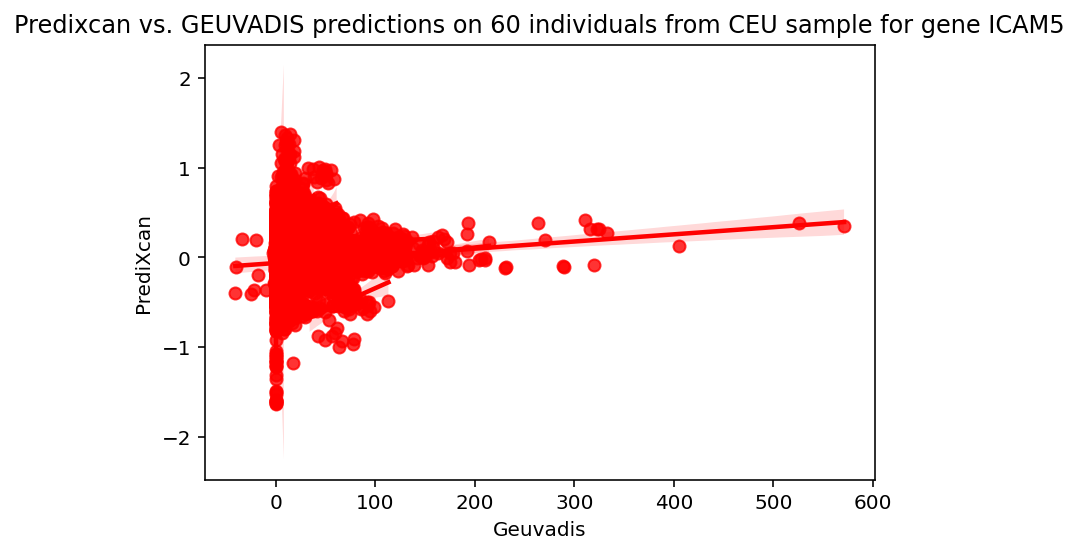

In [66]:
# Create a dataframe to store coef
Geu_Pre_CEU_coef=pd.DataFrame(index=list_of_genes, columns=['Correlation Coefficient'])

# Generating and storing plots for PrediXcan vs Geuvadis on the CEU sample group, store corr_coef along the way
for gene in range(len(list_of_genes)):
  GC=GEU_CEU[list_of_genes[gene]]
  PC=predixcan_CEU[list_of_genes[gene]]
  coef=plot_predixcan_vs_geuvadis(list_of_genes[gene], CEU_individual, GC, PC, 'CEU' )
  Geu_Pre_CEU_coef.loc[list_of_genes[gene]] = coef

Geuvadis vs PredixCan on **YRI sample group**

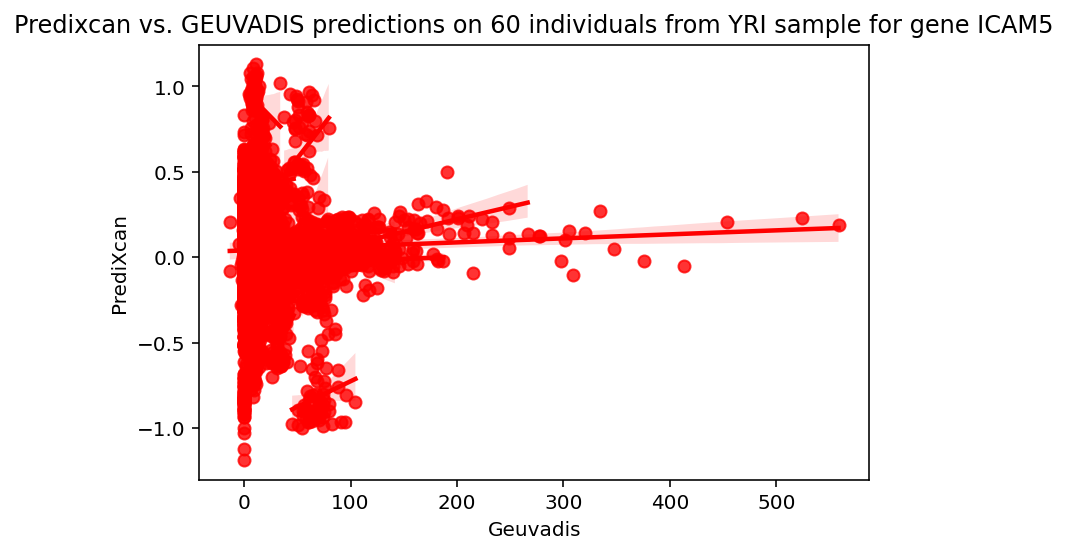

In [67]:
# Create a dataframe to store coef
Geu_Pre_YRI_coef=pd.DataFrame(index=list_of_genes, columns=['Correlation Coefficient'])

# Generating and storing plots for PrediXcan vs Geuvadis on the YRI sample group, store corr_coef along the way
for gene in range(len(list_of_genes)):
  GY=GEU_YRI[list_of_genes[gene]]
  PY=predixcan_YRI[list_of_genes[gene]]
  coef=plot_predixcan_vs_geuvadis(list_of_genes[gene], YRI_individual, GY, PY, 'YRI' )
  Geu_Pre_YRI_coef.loc[list_of_genes[gene]] = coef

### Enformer vs Geuvadis Plotting


CEU group

In [68]:
Enformer_CEU=pd.read_csv("/content/drive/MyDrive/Capstone_Project_2022/results/CEU_Haplotype_Sum.csv", index_col='Unnamed: 0')
Enformer_CEU.head(3)

,SERPINB1,KBTBD2,GCDH,ZNF493,MANBA,ZNF586,THOC3,ZNF567,PCYT1A,PAPD7,...,HELB,SLC16A9,FCRL3,MCM8,MRPL21,FAAH,SLC36A1,PFN2,COG3,ICAM5
NA12340,5394.924,659.66270,1403.4438,1300.4878,7.227004,2679.3396,2925.0542,553.77686,9705.996,101.17969,...,1853.7284,71.676240,2324.1777,3304.2480,13599.494,107.42201,1735.1361,836.4253,2018.5398,12.402702
NA11931,5409.193,665.15765,1398.6799,1302.9343,7.211022,2687.8945,2933.5266,554.41550,9696.058,98.85372,...,1850.0594,73.751800,2320.1720,3307.0486,13788.277,111.30744,1826.4353,826.6749,2022.9392,12.971716
NA12761,5329.963,664.69763,1420.7622,1312.2744,7.242407,2679.2344,2925.4922,488.24643,9501.551,100.09205,...,1866.6755,73.604385,2311.2168,3298.1836,13595.508,110.68312,1722.7316,819.8102,2022.7887,14.750431


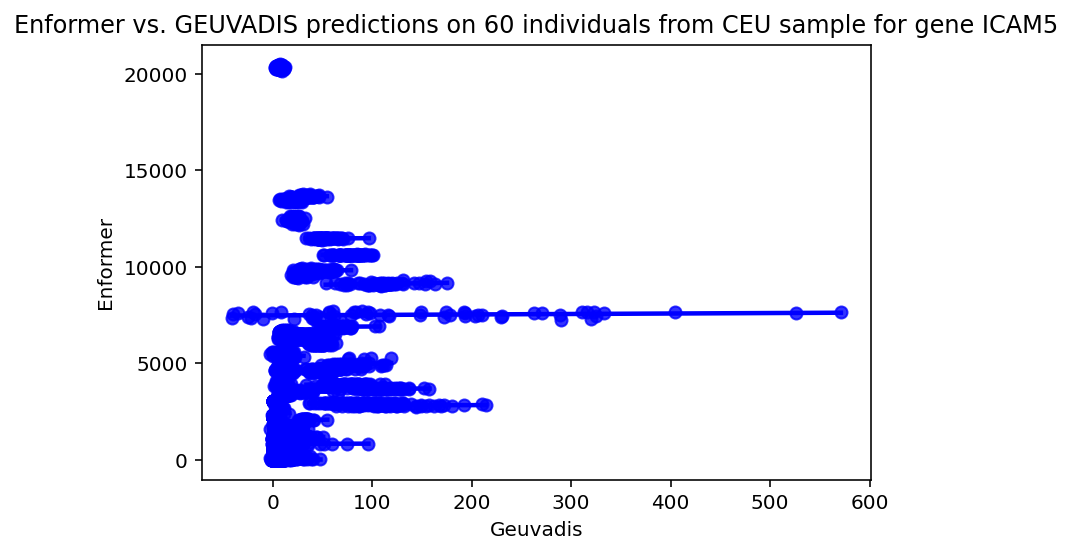

In [69]:
# Create a dataframe to store coef
Geu_Enf_CEU_coef=pd.DataFrame(index=list_of_genes, columns=['Correlation Coefficient'])

# Generating and storing plots for Enformer vs Geuvadis on the CEU sample group, store corr_coef along the way
for gene in range(len(list_of_genes)):
  GC=GEU_CEU[list_of_genes[gene]]
  EC=Enformer_CEU[list_of_genes[gene]]
  coef=plot_enformer_vs_geuvadis(list_of_genes[gene], CEU_individual, GC, EC, 'CEU' )
  Geu_Enf_CEU_coef.loc[list_of_genes[gene]] = coef

**YRI group**

In [70]:
Enformer_YRI=pd.read_csv("/content/drive/MyDrive/Capstone_Project_2022/results/YRI_Haplotype_Sum.csv", index_col='Unnamed: 0')
Enformer_YRI.head(3)

,SERPINB1,KBTBD2,GCDH,ZNF493,MANBA,ZNF586,THOC3,ZNF567,PCYT1A,PAPD7,...,HELB,SLC16A9,FCRL3,MCM8,MRPL21,FAAH,SLC36A1,PFN2,COG3,ICAM5
NA19256,5270.418,659.9147,1400.8744,1296.5131,7.183813,2682.4624,2924.9844,494.85687,9717.023,98.200134,...,1858.6342,71.75763,2334.0684,3313.6687,13634.134,103.440050,1845.7976,828.14624,2008.0933,10.276761
NA19092,5371.596,664.0513,1401.0732,1307.1392,7.201255,2685.8813,2916.2120,554.60180,9645.308,101.850830,...,1847.7634,72.89221,2325.8289,3315.1382,13710.084,102.937660,1844.7812,850.70074,2013.0349,12.407383
NA19147,5478.548,657.7940,1400.6096,1320.8551,7.185963,2684.8093,2915.9536,606.58800,9752.347,98.715546,...,1854.4354,71.71038,2313.3518,3323.3574,13709.168,102.167725,1860.6235,848.95514,2005.2810,12.955041


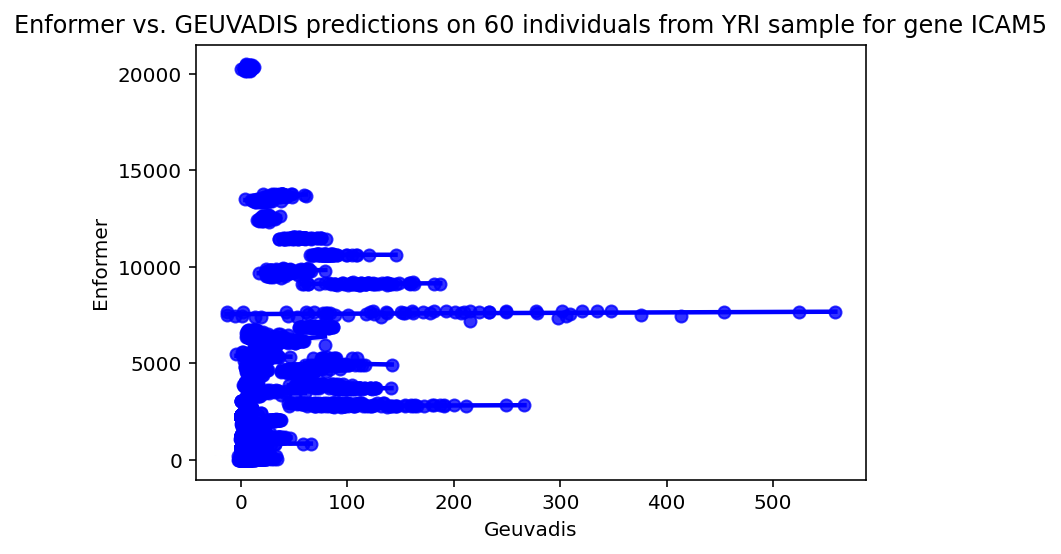

In [71]:
# Create a dataframe to store coef
Geu_Enf_YRI_coef=pd.DataFrame(index=list_of_genes, columns=['Correlation Coefficient'])

# Generating and storing plots for Enformer vs Geuvadis on the CEU sample group, store corr_coef along the way
for gene in range(len(list_of_genes)):
  GY=GEU_YRI[list_of_genes[gene]]
  EY=Enformer_YRI[list_of_genes[gene]]
  coef=plot_enformer_vs_geuvadis(list_of_genes[gene], YRI_individual, GY, EY, 'YRI' )
  Geu_Enf_YRI_coef.loc[list_of_genes[gene]] = coef

### Enformer vs Predixcan

In [72]:
Enformer_YRI=pd.read_csv("/content/drive/MyDrive/Capstone_Project_2022/results/YRI_Haplotype_Sum.csv", index_col='Unnamed: 0')

In [73]:
Enformer_CEU=pd.read_csv("/content/drive/MyDrive/Capstone_Project_2022/results/CEU_Haplotype_Sum.csv", index_col='Unnamed: 0')

##### CEU Group

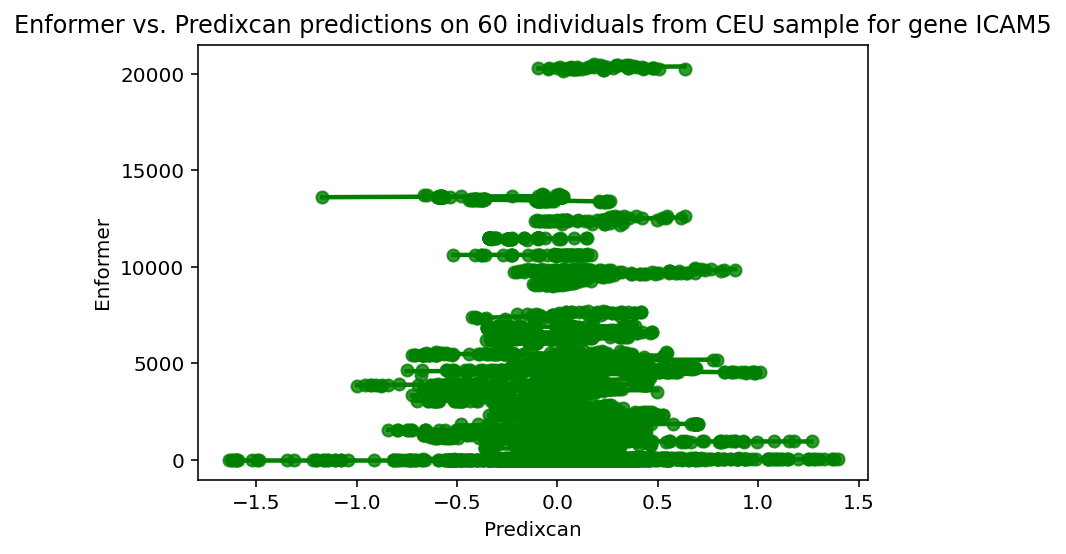

In [74]:
# Create a dataframe to store coef
Enf_Pre_CEU_coef=pd.DataFrame(index=list_of_genes, columns=['Correlation Coefficient'])

# Generating and storing plots for Enformer vs Predixcan on the CEU sample group, store corr_coef along the way
for gene in range(len(list_of_genes)):
  PC=predixcan_CEU[list_of_genes[gene]]
  EC=Enformer_CEU[list_of_genes[gene]]
  coef=plot_enformer_vs_predixcan(list_of_genes[gene], CEU_individual, PC, EC, 'CEU' )
  Enf_Pre_CEU_coef.loc[list_of_genes[gene]] = coef

##### YRI Group

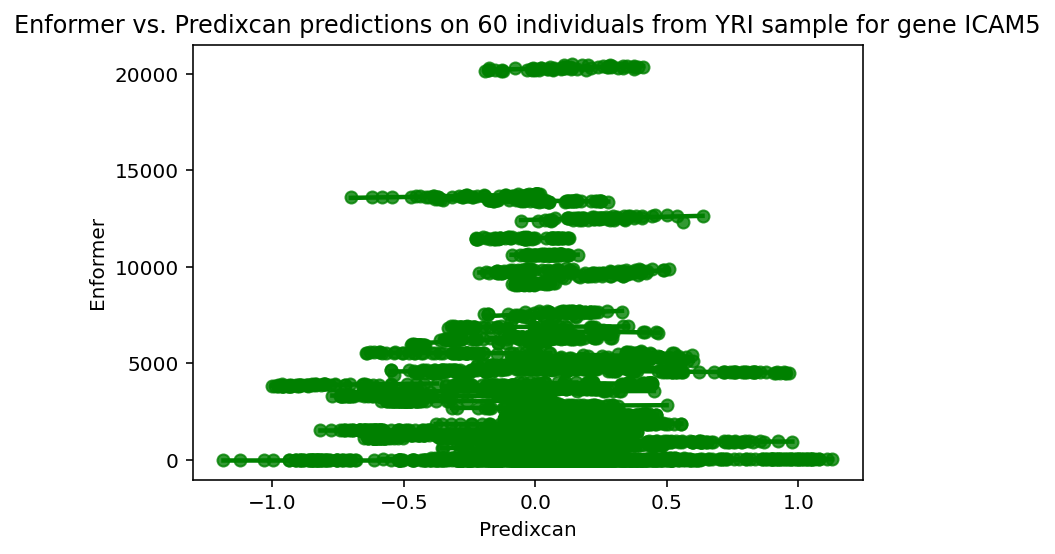

In [75]:
# Create a dataframe to store coef
Enf_Pre_YRI_coef=pd.DataFrame(index=list_of_genes, columns=['Correlation Coefficient'])

# Generating and storing plots for Enformer vs Geuvadis on the CEU sample group, store corr_coef along the way
for gene in range(len(list_of_genes)):
  PY=predixcan_YRI[list_of_genes[gene]]
  EY=Enformer_YRI[list_of_genes[gene]]
  coef=plot_enformer_vs_predixcan(list_of_genes[gene], YRI_individual, PY, EY, 'YRI' )
  Enf_Pre_YRI_coef.loc[list_of_genes[gene]] = coef

## Analysis

### Correlation tables

combine results

compare a scatter plot of E vs P in YRI and CEU. with the identity line.
YRI vs CEU in E and P. compare each gene. 

Do QQ plot. which compares the marginal distribution, not pairs. SORTED

add a column in the correlation table the STRAND info of the gene

These two correlation tables. Each column is the pearson correlation of the model's prediction against the Geuvadis observed value on a specefic gene across the sample group. 

In [76]:
YRI_corr = pd.concat([Geu_Pre_YRI_coef, Geu_Enf_YRI_coef], axis=1)
YRI_corr.columns=['Predixcan','Enformer']
#YRI_corr.to_csv('/content/drive/MyDrive/Capstone_Project_2022/results/Pre_Enf_YRI.csv')

In [77]:
CEU_corr = pd.concat([Geu_Pre_CEU_coef, Geu_Enf_CEU_coef], axis=1)
CEU_corr.columns=['Predixcan','Enformer']
#CEU_corr.to_csv('/content/drive/MyDrive/Capstone_Project_2022/results/Pre_Enf_CEU.csv')

### Plotting correlation graphs

#### Enformer vs Predixcan on YRI and CEU

In [78]:
YRI_E=YRI_corr['Enformer'].astype(float)
YRI_P=YRI_corr['Predixcan'].astype(float)
YRI_E

SERPINB1   -0.067964
KBTBD2      0.133400
GCDH       -0.183083
ZNF493     -0.006718
MANBA       0.297369
              ...   
FAAH        0.117220
SLC36A1     0.018541
PFN2        0.194495
COG3       -0.028420
ICAM5       0.095820
Name: Enformer, Length: 100, dtype: float64

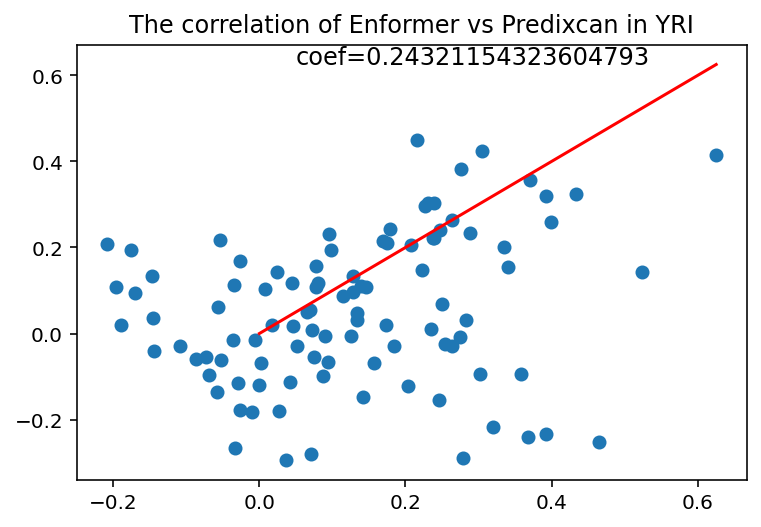

In [79]:
import matplotlib.pyplot as plt


xlim=max(max(abs(YRI_E)), max(abs(YRI_P)))
x = np.linspace(0,xlim,100)
y = x

plt.scatter(x=YRI_P, y=YRI_E) # Plot x vs y
plt.title("The correlation of Enformer vs Predixcan in YRI")
plt.set_xlabel=('Predixcan')
plt.ylabel=('Enformer')

plt.plot(x, y, '-r')

textstr='coef='+str(YRI_E.corr(YRI_P))
plt.text(0.05, xlim, textstr, fontsize=12)
plt.show()

In [80]:
CEU_E=CEU_corr['Enformer'].astype(float)
CEU_P=CEU_corr['Predixcan'].astype(float)

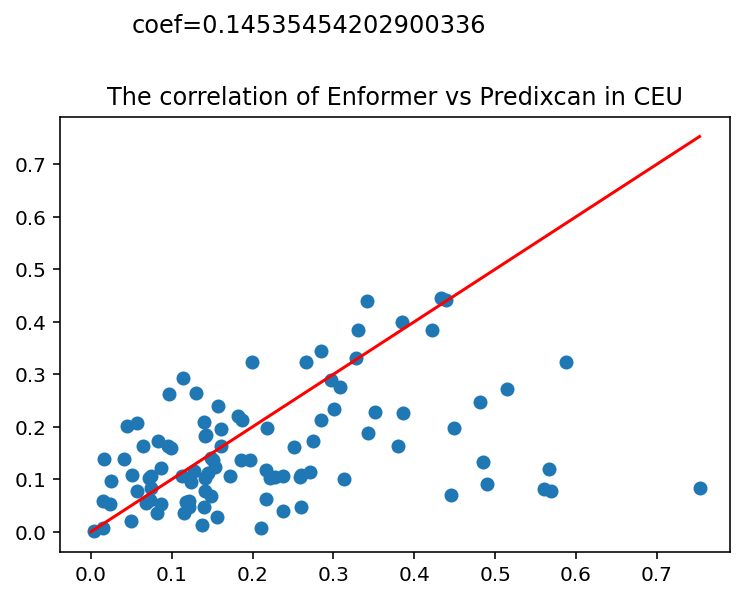

In [81]:
x=max(max(abs(CEU_P)), max(abs(CEU_E)))
plt.scatter(x=abs(CEU_P), y=abs(CEU_E)) # x vs y
x = np.linspace(0,x,100)
y = x

plt.title("The correlation of Enformer vs Predixcan in CEU")
plt.plot(x, y, '-r')

textstr='coef='+str(CEU_E.corr(CEU_P))
plt.text(0.05, 0.95, textstr, fontsize=12)
plt.show()

#### YRI vs CEU in Enformer and Predixcan

In [82]:
YRI_E=YRI_corr['Enformer'].astype(float)
CEU_E=CEU_corr['Enformer'].astype(float)

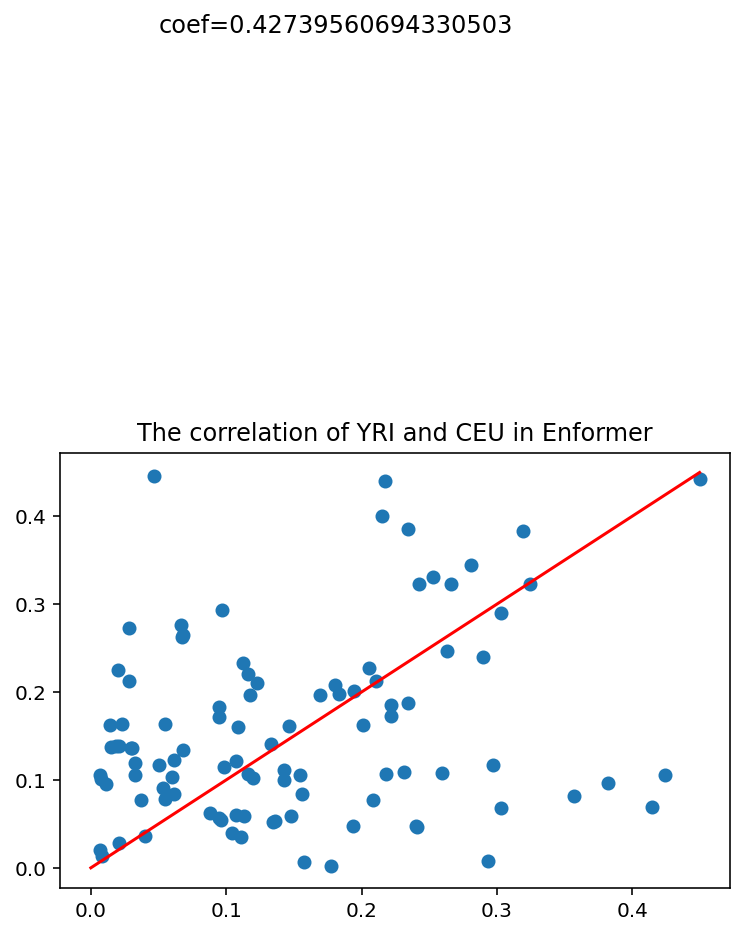

In [83]:
plt.scatter(x=abs(YRI_E), y=abs(CEU_E)) # Plot x vs y

x=max(max(abs(YRI_E)), max(abs(CEU_E)))
x = np.linspace(0,x,100)
y = x

plt.title("The correlation of YRI and CEU in Enformer")
plt.plot(x, y, '-r')

textstr='coef='+str(YRI_E.corr(CEU_E))
plt.text(0.05, 0.95, textstr, fontsize=12)
plt.show()

In [84]:
YRI_P=YRI_corr['Predixcan'].astype(float)
CEU_P=CEU_corr['Predixcan'].astype(float)

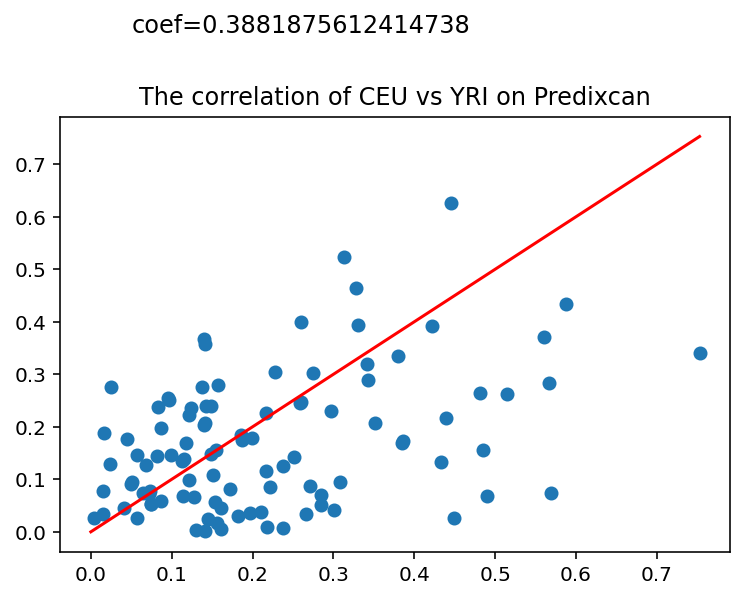

In [85]:
x=max(max(abs(CEU_P)), max(abs(YRI_P)))
plt.scatter(x=abs(CEU_P), y=abs(YRI_P)) # x vs y
x = np.linspace(0,x,100)
y = x

plt.title("The correlation of CEU vs YRI on Predixcan")
plt.plot(x, y, '-r')

textstr='coef='+str(YRI_P.corr(CEU_P))
plt.text(0.05, 0.95, textstr, fontsize=12)
plt.show()